In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_expression.csv to cleaned_expression.csv


In [4]:
df = pd.read_csv("cleaned_expression.csv")

In [5]:
df.head()

,Unnamed: 0,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,Response
0,F71B-Tn-C_S2,50,13,3,11275,48,5851,1,6,146,...,59,325,419,661,533,736,983,4222,2678,1
1,X116BBp-C_S11,42,3,3,14324,182,43,0,2,107,...,343,386,406,1036,211,1001,1419,5564,2709,1
2,X090B-Bn_S6,226,71,0,22473,106,17,0,1,363,...,177,235,323,1119,586,1518,1465,6632,4455,0
3,X047B-Bn-C_S3,121,39,1,12556,121,6,1,1,190,...,222,303,630,736,119,785,1543,4367,2250,1
4,X260B-Bp-C_S5,70,25,17,19076,94,9,0,0,102,...,698,386,647,758,367,1194,1312,5735,2547,1


In [6]:
X = df.drop("Response", axis=1)
y = df["Response"]

group0 = X[y == 0]
group1 = X[y == 1]

print(group0.shape)
print(group1.shape)

(26, 28279)
(25, 28279)


In [8]:
mean0 = group0.mean(numeric_only=True)
mean1 = group1.mean(numeric_only=True)

print(mean0.head())
print(mean1.head())

A1BG          105.384615
A1BG-AS1       30.846154
A1CF            5.846154
A2M         11404.038462
A2M-AS1        78.923077
dtype: float64
A1BG           88.12
A1BG-AS1       26.80
A1CF            7.88
A2M         29088.52
A2M-AS1       111.64
dtype: float64


In [10]:
diff = mean1 - mean0
print(diff)

A1BG          -17.264615
A1BG-AS1       -4.046154
A1CF            2.033846
A2M         17684.481538
A2M-AS1        32.716923
                ...     
ZYG11A         80.155385
ZYG11B        -54.907692
ZYX           238.920000
ZZEF1         511.760000
ZZZ3          114.060000
Length: 28278, dtype: float64


In [11]:
top_genes = diff.abs().sort_values(ascending=False).head(10)
print(top_genes)

print(diff[top_genes.index])

MALAT1      148548.784615
XIST         71441.816923
TALAM1       54927.816923
RNF213       37074.541538
COL1A2       26470.569231
MUC16        24155.600000
SNORD3A      23540.655385
COL3A1       22525.092308
ANKRD30A     19456.352308
LRP2         18658.258462
dtype: float64
MALAT1     -148548.784615
XIST        -71441.816923
TALAM1      -54927.816923
RNF213       37074.541538
COL1A2      -26470.569231
MUC16        24155.600000
SNORD3A      23540.655385
COL3A1      -22525.092308
ANKRD30A    -19456.352308
LRP2        -18658.258462
dtype: float64


<Axes: >

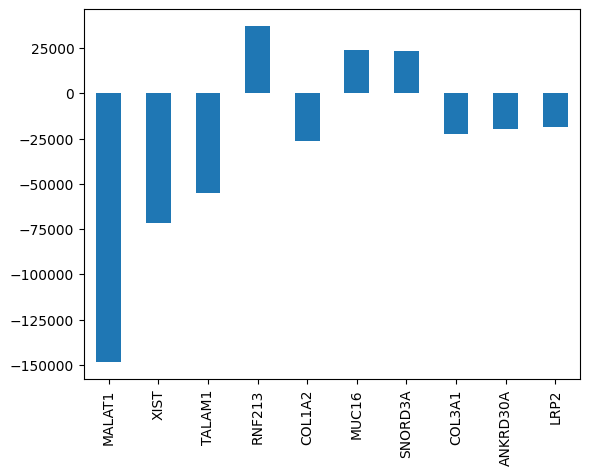

In [12]:
diff[top_genes.index].plot(kind='bar')

In [ ]:
#The analysis identifies genes that differ between treatment responders and non-responders.
#Genes such as MALAT1 and XIST are upregulated in non-responders, while genes like MUC16 and RNF213 are upregulated in responders, suggesting potential molecular differences associated with treatment outcome.